# Recolección y comprensión de datos (secciones 3.2–3.5)

Notebook única del proyecto **Doppler**: Sistema de Reconocimiento Acústico de Vehículos de Emergencia.

**Objetivo:** producir las tablas, figuras y texto de las secciones 3.2–3.5 del informe (adquisición, exploración, variables relevantes y hallazgos). No entrena modelos ni hace el preprocesado de la sección 4.

**Criterio de éxito:**
- Montar (Kaggle Input) o descargar (Colab) los corpora de la sección 3.1.
- Inventariar clases, duraciones y tasas de muestreo sin copiar audio a `/kaggle/working`.
- Extraer descriptores tiempo-frecuencia sobre una muestra estratificada.
- Dejar texto en español listo para pegar en el PDF.

**Runtime:** Kaggle (recomendado) o Google Colab. CPU basta. En Kaggle active Internet solo si falta un Input o corre el fallback de descarga.


## 0. Entorno, rutas e Inputs de Kaggle

En Kaggle el audio **no cabe** en `/kaggle/working` (~20 GB). Cada corpus se publica una vez como *Dataset* y se adjunta con **Add Input**. Queda en `/kaggle/input/<slug>/` (solo lectura). Esta notebook:

1. Detecta Kaggle vs Colab.
2. Resuelve cada corpus por *slug* o por archivos marcadores (`UrbanSound8K.csv`, `EV_Positives.csv`, etc.).
3. Si el Input llega como ZIP/TAR, extrae a `/kaggle/temp` (scratch de sesión).
4. Escribe tablas y figuras solo en `REPORTS` (`/kaggle/working/reports` o `/content/reports`).

Adjunte, como mínimo: LSSiren, sireNNet, AudioSet-EV v2, UrbanSound8K, SONYC-UST v2. ESC-50 es pieza de Unified-EV. RecSIR se **genera** aquí (no hay ZIP público).


In [1]:
# Setup: imports, semilla y detección de runtime
from __future__ import annotations

import hashlib
import io
import json
import os
import random
import shutil
import subprocess
import sys
import tarfile
import warnings
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
warnings.filterwarnings("ignore", category=UserWarning)

IN_KAGGLE = Path("/kaggle/input").exists()
IN_COLAB = False
try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    pass

if IN_KAGGLE:
    INPUT_ROOT = Path("/kaggle/input")
    WORK = Path("/kaggle/working")
    TEMP = Path("/kaggle/temp")
    if not TEMP.exists():
        TEMP = Path("/tmp")
    DATA_ROOT = TEMP / "doppler-data"
    REPORTS = WORK / "reports"
elif IN_COLAB:
    INPUT_ROOT = Path("/content/doppler-data")
    WORK = Path("/content")
    DATA_ROOT = Path("/content/doppler-data")
    REPORTS = Path("/content/reports")
else:
    INPUT_ROOT = Path.cwd() / "data" / "raw"
    WORK = Path.cwd()
    DATA_ROOT = INPUT_ROOT
    REPORTS = Path.cwd() / "reports"

TABLES = REPORTS / "tables"
FIGURES = REPORTS / "figures"
RECSIR_DIR = WORK / "recsir_demo"
for p in (DATA_ROOT, TABLES, FIGURES, RECSIR_DIR):
    p.mkdir(parents=True, exist_ok=True)

# SMOKE=True: 1 archivo por corpus, para validar la tubería en minutos.
# DOWNLOAD_MISSING: en Colab True por defecto; en Kaggle False (use Add Input).
SMOKE = False
DOWNLOAD_MISSING = False
SAMPLE_PER_CORPUS = 8 if SMOKE else 200
MAX_SPECTROGRAMS = 4 if SMOKE else 8
SR_REC = 8000

print(
    {
        "kaggle": IN_KAGGLE,
        "colab": IN_COLAB,
        "input_root": str(INPUT_ROOT),
        "data_root": str(DATA_ROOT),
        "reports": str(REPORTS),
        "smoke": SMOKE,
        "download_missing": DOWNLOAD_MISSING,
        "sample_per_corpus": SAMPLE_PER_CORPUS,
        "sr_recsir": SR_REC,
    }
)


{'kaggle': True, 'colab': True, 'input_root': '/kaggle/input', 'data_root': '/tmp/doppler-data', 'reports': '/kaggle/working/reports', 'smoke': False, 'download_missing': False, 'sample_per_corpus': 200, 'sr_recsir': 8000}


In [2]:
# Paquetes de audio / plots (Kaggle ya trae la mayoría)
def _pip(*pkgs: str) -> None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])


for pkg in ("librosa", "soundfile", "seaborn", "tqdm"):
    try:
        __import__(pkg if pkg != "soundfile" else "soundfile")
    except ImportError:
        _pip(pkg)

import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import soundfile as sf
from tqdm.auto import tqdm

from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.bbox"] = "tight"

AUDIO_EXTS = {".wav", ".flac", ".ogg", ".mp3", ".aiff", ".aif"}

recsir_df = pd.DataFrame()
unified = pd.DataFrame()
inventory = pd.DataFrame()
feat_df = pd.DataFrame()


### Cómo publicar cada corpus en Kaggle (una sola vez)

1. Descargue el archivo **oficial** en Colab o en su PC (no en `/kaggle/working` del notebook de análisis).
2. Kaggle → **Add Input → New Dataset** (o *New Dataset* desde la página de Datasets). Un dataset por fuente. Suba el ZIP/TAR oficial.
3. En este notebook: **Add Input** y adjunte todos los datasets.
4. UrbanSound8K y ESC-50 ya existen como datasets públicos: puede adjuntarlos en lugar de re-subirlos.

| Corpus | Slugs que busca la notebook | Archivo oficial |
|---|---|---|
| LSSiren | `lssiren`, `large-scale-audio-dataset-for-emergency-vehicle` | Figshare 19291472 (dos ZIP + CSV) |
| sireNNet | `sirennet`, `j4ydzzv4kb` | Mendeley `j4ydzzv4kb-1.zip` |
| AudioSet-EV v2 | `audioset-ev-v2`, `audioset-ev` | Zenodo `AudioSet-EV_v2_main.zip` |
| UrbanSound8K | `urbansound8k` | Zenodo `UrbanSound8K.tar.gz` o dataset público |
| SONYC-UST v2 | `sonyc-ust-v2`, `sonyc-ust` | Zenodo 3966543 (`annotations.csv` + `audio-*.tar.gz`) |
| ESC-50 | `esc50`, `esc-50` | GitHub/Zenodo ESC-50 |

Si el slug no coincide, igual funciona: se buscan archivos marcadores dentro de `/kaggle/input`.


In [3]:
# Catálogo de corpora y resolución de Inputs
CORPORA = {
    "lssiren": {
        "nombre": "LSSiren (Large-Scale Audio Dataset for Emergency Vehicle Sirens and Road Noises)",
        "licencia": "CC0 (Figshare); artículo Scientific Data en CC BY 4.0",
        "n_esperado": "1 800 WAV (900 sirena / 900 ruido), 3–15 s",
        "peso": "~2.3 GB zip / ~2.7 GB audio",
        "url": "https://doi.org/10.6084/m9.figshare.19291472",
        "rol": "Positivos/negativos reales; test OOD binario",
        "slugs": ("lssiren", "large-scale-audio-dataset-for-emergency-vehicle", "19291472"),
        "markers": ("Ambulance_final.csv", "Road_final.csv"),
        "downloads": [
            {
                "url": "https://ndownloader.figshare.com/files/34272599",
                "name": "Emergency_Vehicle_Sirens.zip",
            },
            {
                "url": "https://ndownloader.figshare.com/files/34272605",
                "name": "Road_Noises.zip",
            },
            {
                "url": "https://ndownloader.figshare.com/files/34272593",
                "name": "Ambulance_final.csv",
            },
            {
                "url": "https://ndownloader.figshare.com/files/34272596",
                "name": "Road_final.csv",
            },
        ],
    },
    "sirennet": {
        "nombre": "sireNNet — Emergency Vehicle Siren Classification",
        "licencia": "CC BY 4.0",
        "n_esperado": "1 675 clips (Ambulance 400, Police 454, Firetruck 400, Traffic 421)",
        "peso": "~0.8 GB",
        "url": "https://data.mendeley.com/datasets/j4ydzzv4kb/1",
        "rol": "Multiclase (tipo de vehículo); OOD opcional",
        "slugs": ("sirennet", "j4ydzzv4kb", "sirennet-emergency-vehicle-siren-classification", "sireNNet"),
        "markers": (),
        "class_dirs": ("ambulance", "police", "firetruck", "traffic"),
        "downloads": [
            {
                "url": "https://prod-dcd-datasets-cache-zipfiles.s3.eu-west-1.amazonaws.com/j4ydzzv4kb-1.zip",
                "name": "j4ydzzv4kb-1.zip",
            }
        ],
    },
    "audioset_ev": {
        "nombre": "AudioSet-EV v2",
        "licencia": "CC BY-SA 4.0 (metadatos/curaduría) + ToS de YouTube (clips)",
        "n_esperado": "7 900 positivos + 20 916 negativos; WAV mono 32 kHz ~10 s",
        "peso": "16.2 GB zip / ~28 GB extraído",
        "url": "https://doi.org/10.5281/zenodo.18668076",
        "rol": "Entrenamiento principal binario y 4 vías (police/ambulance/fire/neg)",
        "slugs": ("audioset-ev-v2", "audioset-ev", "audiosetev"),
        "markers": ("EV_Positives.csv", "EV_Negatives.csv"),
        "downloads": [
            {
                "url": "https://zenodo.org/records/18668076/files/AudioSet-EV_v2_main.zip?download=1",
                "name": "AudioSet-EV_v2_main.zip",
                "md5": "25a8984988d1f5285bea3fc25e410dd7",
            }
        ],
    },
    "urbansound8k": {
        "nombre": "UrbanSound8K",
        "licencia": "CC BY-NC 3.0 (uso académico no comercial)",
        "n_esperado": "8 732 clips ≤4 s, 10 clases (siren = 929 slices / ~74 grabaciones)",
        "peso": "6.0 GB",
        "url": "https://doi.org/10.5281/zenodo.1203745",
        "rol": "Negativos urbanos y distractores; la clase siren NO es EV",
        "slugs": ("urbansound8k", "urban-sound-8k", "urbansound8k-dataset"),
        "markers": ("UrbanSound8K.csv",),
        "downloads": [
            {
                "url": "https://zenodo.org/records/1203745/files/UrbanSound8K.tar.gz?download=1",
                "name": "UrbanSound8K.tar.gz",
                "md5": "9aa69802bbf37fb986f71ec1483a196e",
            }
        ],
    },
    "sonyc_ust": {
        "nombre": "SONYC-UST v2.3",
        "licencia": "CC BY 4.0",
        "n_esperado": "18 515 grabaciones de 10 s (Nueva York)",
        "peso": "13.3 GB",
        "url": "https://doi.org/10.5281/zenodo.3966543",
        "rol": "Ruido de fondo para mezclas SNR; podar siren/alarm",
        "slugs": ("sonyc-ust-v2", "sonyc-ust", "sonycust"),
        "markers": ("annotations.csv",),
        "downloads": [
            {
                "url": "https://zenodo.org/records/3966543/files/annotations.csv?download=1",
                "name": "annotations.csv",
            }
        ],
    },
    "esc50": {
        "nombre": "ESC-50",
        "licencia": "CC BY-NC 3.0",
        "n_esperado": "2 000 clips, 50 clases, 5-fold",
        "peso": "~0.6 GB",
        "url": "https://github.com/karolpiczak/ESC-50",
        "rol": "Pieza de Unified-EV (generalización / OOD)",
        "slugs": ("esc50", "esc-50", "environmental-sound-classification-50"),
        "markers": ("esc50.csv",),
        "downloads": [
            {
                "url": "https://github.com/karolpiczak/ESC-50/archive/refs/heads/master.zip",
                "name": "ESC-50-master.zip",
            }
        ],
    },
}


def _iter_input_dirs() -> list[Path]:
    roots = []

    if IN_KAGGLE and INPUT_ROOT.exists():
        roots.extend(
            p for p in INPUT_ROOT.rglob("*")
            if p.is_dir()
        )

    if DATA_ROOT.exists():
        roots.append(DATA_ROOT)
        roots.extend(
            p for p in DATA_ROOT.rglob("*")
            if p.is_dir()
        )

    return roots


def _has_class_dirs(root: Path, names: tuple[str, ...]) -> bool:
    found = {n.lower() for n in names}
    hits = 0
    for p in list(root.iterdir()) + list(root.glob("*/*"))[:80]:
        if p.is_dir() and p.name.lower() in found:
            hits += 1
        if hits >= 3:
            return True
    return False


def _find_marker(root: Path, markers: tuple[str, ...]) -> Path | None:
    if not markers:
        return None

    for marker in markers:
        hits = list(root.rglob(marker))
        if hits:
            return hits[0]

    return None


def resolve_corpus(key: str) -> Path | None:
    spec = CORPORA[key]

    for folder in _iter_input_dirs():
        slug = folder.name.lower()

        if any(s.lower() == slug for s in spec["slugs"]):
            # ESC-50: el dataset real está en la carpeta que contiene audio/ y meta/
            if key == "esc50":
                if (folder / "audio").exists() and (folder / "meta" / "esc50.csv").exists():
                    return folder

            return folder

    # búsqueda adicional por CSV
    marker = _find_marker(INPUT_ROOT, spec.get("markers", ()))

    if marker is not None:
        if key == "esc50":
            # esc50.csv -> meta -> esc50
            dataset_root = marker.parent.parent
            if (dataset_root / "audio").exists():
                return dataset_root

        return marker.parent

    return None


def list_audio(root: Path, limit: int | None = None) -> list[Path]:
    files: list[Path] = []
    if root is None or not root.exists():
        return files
    for p in root.rglob("*"):
        if p.is_file() and p.suffix.lower() in AUDIO_EXTS:
            files.append(p)
            if limit is not None and len(files) >= limit:
                break
    return files


def md5_ok(path: Path, expected: str | None) -> bool:
    if not expected or not path.exists():
        return True
    h = hashlib.md5()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest() == expected


def download_file(url: str, dest: Path, expected_md5: str | None = None) -> Path:
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists() and dest.stat().st_size > 0 and md5_ok(dest, expected_md5):
        print(f"ya existe: {dest.name}")
        return dest
    print(f"descargando {url} -> {dest}")
    try:
        subprocess.check_call(["wget", "-c", "-O", str(dest), url])
    except (FileNotFoundError, subprocess.CalledProcessError):
        import urllib.request

        urllib.request.urlretrieve(url, dest)
    if expected_md5 and not md5_ok(dest, expected_md5):
        raise RuntimeError(f"MD5 incorrecto para {dest}")
    return dest


def extract_archive(archive: Path, dest: Path) -> Path:
    dest.mkdir(parents=True, exist_ok=True)
    name = archive.name.lower()
    print(f"extrayendo {archive.name} -> {dest}")
    if name.endswith(".zip"):
        with zipfile.ZipFile(archive) as zf:
            zf.extractall(dest)
    elif name.endswith(".tar.gz") or name.endswith(".tgz") or name.endswith(".tar"):
        mode = "r:gz" if name.endswith(("gz", "tgz")) else "r"
        with tarfile.open(archive, mode) as tf:
            tf.extractall(dest)
    return dest


def _shallow_archives(root: Path) -> list[Path]:
    hits: list[Path] = []
    candidates = list(root.iterdir())
    candidates.extend(list(root.glob("*/*"))[:40])
    for p in candidates:
        if not p.is_file():
            continue
        name = p.name.lower()
        if name.endswith((".zip", ".tar.gz", ".tgz", ".tar")):
            hits.append(p)
    return hits


def maybe_extract_inputs(root: Path, dest: Path) -> Path:
    """Si el Input es un archivo comprimido, extrae a scratch (no a /kaggle/working)."""
    audio_already = list_audio(root, limit=3)
    if audio_already:
        return root
    archives = _shallow_archives(root)
    if not archives:
        return root
    dest.mkdir(parents=True, exist_ok=True)
    for arch in archives:
        extract_archive(arch, dest)
    return dest


MOUNTS: dict[str, Path | None] = {k: resolve_corpus(k) for k in CORPORA}
mount_rows = []
for key, spec in CORPORA.items():
    path = MOUNTS[key]
    n_audio = len(list_audio(path, limit=None)) if path is not None else 0
    mount_rows.append(
        {
            "corpus": key,
            "estado": "montado" if path is not None else "faltante",
            "ruta": str(path) if path is not None else "",
            "n_audio_visto": n_audio,
            "nombre": spec["nombre"],
        }
    )
mount_df = pd.DataFrame(mount_rows)
mount_df.to_csv(TABLES / "mount_status.csv", index=False)
display(mount_df)
print("Inputs en", INPUT_ROOT)
if IN_KAGGLE and INPUT_ROOT.exists():
    print(sorted(p.name for p in INPUT_ROOT.iterdir()))


,corpus,estado,ruta,n_audio_visto,nombre
0,lssiren,montado,/kaggle/input/datasets/jeancdevx/lssiren,1834,LSSiren (Large-Scale Audio Dataset for Emergen...
1,sirennet,montado,/kaggle/input/datasets/jeancdevx/sirennet,1675,sireNNet — Emergency Vehicle Siren Classification
2,audioset_ev,montado,/kaggle/input/datasets/jeancdevx/audioset-ev,28816,AudioSet-EV v2
3,urbansound8k,montado,/kaggle/input/datasets/jeancdevx/urbansound8k,8732,UrbanSound8K
4,sonyc_ust,montado,/kaggle/input/datasets/jeancdevx/sonyc-ust,18510,SONYC-UST v2.3
5,esc50,montado,/kaggle/input/datasets/jeancdevx/esc-50,2000,ESC-50


Inputs en /kaggle/input
['datasets']


## Plan de esta notebook

- **3.2** Tabla de adquisición (nombre, licencia, cantidad, URL, rol), estado de montaje, descarga solo si falta, índice Unified-EV, demo RecSIR y aumentación.
- **3.3** Inventario (clases, duración, sr), fugas (`fsID`, `yt_id`), espectrogramas de ejemplo.
- **3.4** RMS, ZCR, MFCC, centroide, bandwidth, roll-off, flujo; Doppler estático vs RecSIR.
- **3.5** Hallazgos e implicaciones para la sección 4.

Hipótesis de trabajo: los corpora no son i.i.d.; hay *domain shift* (sr, duración, etiquetado débil vs fuerte) y la clase `siren` de UrbanSound8K no equivale a vehículo de emergencia.


## 3.2 Proceso de adquisición

La sección 3.1 del informe define una estrategia **híbrida y multicondición**. Aquí se aterriza cómo se obtiene cada fuente, con qué licencia y qué papel cumple. RecSIR/SynSIR **no se descargan**: Damiano et al. (2024) los generan con `pyroadacoustics`. AudioSet-EV Augmented es aumentación *online*. Unified-EV es un **índice** que une corpora con disyunción de etiquetas, no un dump extra de WAV.


In [4]:
# Tabla de adquisición (texto del informe 3.2)
catalog = pd.DataFrame(
    [
        {
            "dataset": spec["nombre"],
            "licencia": spec["licencia"],
            "cantidad": spec["n_esperado"],
            "tamano": spec["peso"],
            "url": spec["url"],
            "rol_en_el_corpus": spec["rol"],
            "estado_sesion": MOUNTS[key] is not None,
        }
        for key, spec in CORPORA.items()
    ]
    + [
        {
            "dataset": "RecSIR / SynSIR (generado)",
            "licencia": "Código pyroadacoustics (open); fuentes LSSiren/sireNNet + ruido SONYC/US8K",
            "cantidad": "Paper: 24 000 × 2 s. Esta notebook: demo Doppler×SNR (no 24k)",
            "tamano": "generado en sesión (cientos de clips)",
            "url": "https://github.com/steDamiano/pyroadacoustics",
            "rol_en_el_corpus": "Efecto Doppler, SNR controlado (−10 a +10 dB)",
            "estado_sesion": RECSIR_DIR.exists(),
        },
        {
            "dataset": "FSD50K (opcional, Unified-EV)",
            "licencia": "CC BY 4.0 (clips Freesound con atribución)",
            "cantidad": "~51 k clips, ~200 clases",
            "tamano": "~31 GB",
            "url": "https://doi.org/10.5281/zenodo.4060432",
            "rol_en_el_corpus": "OOD extra; no se monta por defecto",
            "estado_sesion": False,
        },
    ]
)
catalog.to_csv(TABLES / "corpus_catalog.csv", index=False)
pd.set_option("display.max_colwidth", 80)
display(catalog)


,dataset,licencia,cantidad,tamano,url,rol_en_el_corpus,estado_sesion
0,LSSiren (Large-Scale Audio Dataset for Emergency Vehicle Sirens and Road Noi...,CC0 (Figshare); artículo Scientific Data en CC BY 4.0,"1 800 WAV (900 sirena / 900 ruido), 3–15 s",~2.3 GB zip / ~2.7 GB audio,https://doi.org/10.6084/m9.figshare.19291472,Positivos/negativos reales; test OOD binario,True
1,sireNNet — Emergency Vehicle Siren Classification,CC BY 4.0,"1 675 clips (Ambulance 400, Police 454, Firetruck 400, Traffic 421)",~0.8 GB,https://data.mendeley.com/datasets/j4ydzzv4kb/1,Multiclase (tipo de vehículo); OOD opcional,True
2,AudioSet-EV v2,CC BY-SA 4.0 (metadatos/curaduría) + ToS de YouTube (clips),7 900 positivos + 20 916 negativos; WAV mono 32 kHz ~10 s,16.2 GB zip / ~28 GB extraído,https://doi.org/10.5281/zenodo.18668076,Entrenamiento principal binario y 4 vías (police/ambulance/fire/neg),True
3,UrbanSound8K,CC BY-NC 3.0 (uso académico no comercial),"8 732 clips ≤4 s, 10 clases (siren = 929 slices / ~74 grabaciones)",6.0 GB,https://doi.org/10.5281/zenodo.1203745,Negativos urbanos y distractores; la clase siren NO es EV,True
4,SONYC-UST v2.3,CC BY 4.0,18 515 grabaciones de 10 s (Nueva York),13.3 GB,https://doi.org/10.5281/zenodo.3966543,Ruido de fondo para mezclas SNR; podar siren/alarm,True
5,ESC-50,CC BY-NC 3.0,"2 000 clips, 50 clases, 5-fold",~0.6 GB,https://github.com/karolpiczak/ESC-50,Pieza de Unified-EV (generalización / OOD),True
6,RecSIR / SynSIR (generado),Código pyroadacoustics (open); fuentes LSSiren/sireNNet + ruido SONYC/US8K,Paper: 24 000 × 2 s. Esta notebook: demo Doppler×SNR (no 24k),generado en sesión (cientos de clips),https://github.com/steDamiano/pyroadacoustics,"Efecto Doppler, SNR controlado (−10 a +10 dB)",True
7,"FSD50K (opcional, Unified-EV)",CC BY 4.0 (clips Freesound con atribución),"~51 k clips, ~200 clases",~31 GB,https://doi.org/10.5281/zenodo.4060432,OOD extra; no se monta por defecto,False


### Descarga fallback (Colab o Input faltante)

En Kaggle deje `DOWNLOAD_MISSING = False` y use **Add Input**. En Colab la celda baja el archivo oficial a `/content/doppler-data` (resume con `wget -c`) y extrae ahí. AudioSet-EV y SONYC son pesados: baje AudioSet-EV **primero** si el disco está vacío.

SONYC completo son ~19 archivos `audio-*.tar.gz`. Por defecto solo se descarga `annotations.csv`; los tarballs de audio se listan para que los suba como Input.


In [5]:
# Descarga solo corpora faltantes (no escribe en /kaggle/working)
SONYC_AUDIO_URLS = [
    f"https://zenodo.org/records/3966543/files/audio-{i}.tar.gz?download=1" for i in range(19)
]


def acquire(key: str) -> Path | None:
    current = resolve_corpus(key)
    if current is not None:
        return current
    if not DOWNLOAD_MISSING:
        print(f"[skip] {key} no montado y DOWNLOAD_MISSING=False")
        return None
    spec = CORPORA[key]
    dest = DATA_ROOT / key
    dest.mkdir(parents=True, exist_ok=True)
    items = list(spec["downloads"])
    if key == "sonyc_ust" and not SMOKE:
        print("SONYC audio: suba los tar.gz como Kaggle Input; aquí solo annotations.csv.")
    for item in items:
        path = download_file(item["url"], dest / item["name"], item.get("md5"))
        if path.suffix.lower() in {".zip", ".gz", ".tgz"} or path.name.endswith(".tar.gz"):
            extract_archive(path, dest)
            try:
                path.unlink()
            except OSError:
                pass
    MOUNTS[key] = resolve_corpus(key) or dest
    return MOUNTS[key]


if DOWNLOAD_MISSING:
    order = ["audioset_ev", "sonyc_ust", "urbansound8k", "lssiren", "sirennet", "esc50"]
    for key in order:
        if SMOKE and key in {"audioset_ev", "sonyc_ust"}:
            print(f"[smoke] no se descarga {key} completo")
            continue
        acquire(key)
else:
    print("Modo Kaggle Input: no se descargan corpora. Adjúntelos con Add Input.")

# Extraer ZIP de Inputs a scratch si no hay WAV visibles
for key, path in list(MOUNTS.items()):
    if path is None:
        continue
    extracted = maybe_extract_inputs(path, DATA_ROOT / key)
    if extracted != path:
        MOUNTS[key] = extracted

mount_df = pd.DataFrame(
    [
        {
            "corpus": k,
            "estado": "montado" if MOUNTS[k] is not None else "faltante",
            "ruta": str(MOUNTS[k] or ""),
            "n_audio": len(list_audio(MOUNTS[k])) if MOUNTS[k] is not None else 0,
        }
        for k in CORPORA
    ]
)
mount_df.to_csv(TABLES / "mount_status.csv", index=False)
display(mount_df)


Modo Kaggle Input: no se descargan corpora. Adjúntelos con Add Input.


,corpus,estado,ruta,n_audio
0,lssiren,montado,/kaggle/input/datasets/jeancdevx/lssiren,1834
1,sirennet,montado,/kaggle/input/datasets/jeancdevx/sirennet,1675
2,audioset_ev,montado,/kaggle/input/datasets/jeancdevx/audioset-ev,28816
3,urbansound8k,montado,/kaggle/input/datasets/jeancdevx/urbansound8k,8732
4,sonyc_ust,montado,/kaggle/input/datasets/jeancdevx/sonyc-ust,18510
5,esc50,montado,/kaggle/input/datasets/jeancdevx/esc-50,2000


### RecSIR demo (Doppler + SNR)

Se sintetiza una sirena tipo *wail* y, si `pyroadacoustics` está disponible, se simula una trayectoria recta (fuente en movimiento, micrófono estático). Si el paquete falla, hay un fallback de *pitch shift* + mezcla a SNR conocido. El paper usa 24 000 clips; aquí solo una malla pequeña para el EDA.


In [6]:
# RecSIR / SynSIR de demostración
def synth_wail(sr: int, duration: float = 2.0) -> np.ndarray:
    t = np.arange(int(sr * duration)) / sr
    lfo = 0.5 + 0.5 * np.sin(2 * np.pi * 1.8 * t)
    freq = 650 + 550 * lfo
    phase = np.cumsum(2 * np.pi * freq / sr)
    y = 0.35 * np.sin(phase) + 0.12 * np.sin(2 * phase)
    fade = np.hanning(len(y))
    fade = np.minimum(fade * 8, 1.0)
    return (y * fade).astype(np.float32)


def mix_snr(signal: np.ndarray, noise: np.ndarray, snr_db: float) -> np.ndarray:
    n = min(len(signal), len(noise))
    s = signal[:n].astype(np.float64)
    z = noise[:n].astype(np.float64)
    if np.std(z) < 1e-9:
        z = np.random.randn(n)
    s_pow = np.mean(s**2) + 1e-12
    z_pow = np.mean(z**2) + 1e-12
    z = z * np.sqrt(s_pow / (z_pow * 10 ** (snr_db / 10)))
    out = s + z
    peak = np.max(np.abs(out)) + 1e-9
    return (out / peak * 0.89).astype(np.float32)


def fallback_doppler(y: np.ndarray, sr: int, speed_mps: float) -> np.ndarray:
    # Aproximación: corrimiento de tono proporcional a v/c (c ≈ 343 m/s).
    ratio = 343.0 / max(343.0 - speed_mps, 50.0)
    n_out = int(len(y) / ratio)
    x = np.linspace(0, len(y) - 1, n_out)
    stretched = np.interp(x, np.arange(len(y)), y)
    n_steps = min(8, max(3, int(abs(speed_mps) / 5) + 2))
    pieces = np.array_split(stretched, n_steps)
    shifted = []
    for i, piece in enumerate(pieces):
        n_semitones = (i / max(n_steps - 1, 1) - 0.5) * (speed_mps / 10.0)
        shifted.append(librosa.effects.pitch_shift(piece.astype(float), sr=sr, n_steps=n_semitones))
    out = np.concatenate(shifted)
    target = int(2.0 * sr)
    if len(out) < target:
        out = np.pad(out, (0, target - len(out)))
    return out[:target].astype(np.float32)


def load_noise_clip(sr: int, duration: float = 2.0) -> np.ndarray:
    n = int(sr * duration)
    for key in ("sonyc_ust", "urbansound8k", "lssiren"):
        root = MOUNTS.get(key)
        files = list_audio(root, limit=40) if root else []
        if not files:
            continue
        path = random.choice(files)
        try:
            y, _ = librosa.load(path, sr=sr, duration=duration, mono=True)
            if len(y) >= n // 2:
                if len(y) < n:
                    y = np.pad(y, (0, n - len(y)))
                return y[:n]
        except Exception:
            continue
    return (0.02 * np.random.randn(n)).astype(np.float32)


def simulate_pyroad(src: np.ndarray, sr: int, speed: float, snr_db: float, noise: np.ndarray):
    import pyroadacoustics as pyroad

    env = pyroad.Environment(fs=sr, temperature=20, pressure=1, rel_humidity=50)
    env.add_source(
        position=np.array([3, 20, 1]),
        signal=src,
        trajectory_points=np.array([[3, 20, 1], [3, -20, 1]]),
        source_velocity=np.array([max(speed, 0.5)]),
    )
    env.add_microphone_array(np.array([[0, 0, 1]]))
    env.set_background_noise(noise, SNR=snr_db)
    env.set_simulation_params("Allpass", True, True)
    captured = env.simulate()
    y = np.asarray(captured[0], dtype=np.float32)
    return y


HAS_PYROAD = False
try:
    import pyroadacoustics  # noqa: F401

    HAS_PYROAD = True
except ImportError:
    try:
        _pip("pyroadacoustics")
        import pyroadacoustics  # noqa: F401

        HAS_PYROAD = True
    except Exception as exc:
        print("pyroadacoustics no disponible, se usa fallback Doppler:", exc)

SR_REC = 8000
speeds = [5.0, 20.0] if SMOKE else [5.0, 15.0, 30.0, 40.0]
snrs = [0.0, 10.0] if SMOKE else [-10.0, -5.0, 0.0, 10.0]
src = synth_wail(SR_REC, 2.0)
noise = load_noise_clip(SR_REC, 2.0)
recsir_rows = []
engine = "pyroadacoustics" if HAS_PYROAD else "fallback_pitch"

for speed in speeds:
    for snr_db in snrs:
        try:
            if HAS_PYROAD:
                y = simulate_pyroad(src, SR_REC, speed, snr_db, noise)
            else:
                y = mix_snr(fallback_doppler(src, SR_REC, speed), noise, snr_db)
        except Exception as exc:
            print("simulación falló, fallback:", exc)
            y = mix_snr(fallback_doppler(src, SR_REC, speed), noise, snr_db)
            engine = "fallback_pitch"
        fname = RECSIR_DIR / f"recsir_v{int(speed)}_snr{int(snr_db)}.wav"
        sf.write(fname, y, SR_REC)
        recsir_rows.append(
            {
                "path": str(fname),
                "speed_mps": speed,
                "snr_db": snr_db,
                "sr": SR_REC,
                "engine": engine,
                "duration_s": len(y) / SR_REC,
            }
        )

recsir_df = pd.DataFrame(recsir_rows)
recsir_df.to_csv(TABLES / "recsir_demo_index.csv", index=False)
display(recsir_df)
print(f"{len(recsir_df)} clips RecSIR en {RECSIR_DIR}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.1/45.1 kB 524.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 1.4 MB/s eta 0:00:00


,path,speed_mps,snr_db,sr,engine,duration_s
0,/kaggle/working/recsir_demo/recsir_v5_snr-10.wav,5.0,-10.0,8000,pyroadacoustics,8.000000
1,/kaggle/working/recsir_demo/recsir_v5_snr-5.wav,5.0,-5.0,8000,pyroadacoustics,8.000000
2,/kaggle/working/recsir_demo/recsir_v5_snr0.wav,5.0,0.0,8000,pyroadacoustics,8.000000
3,/kaggle/working/recsir_demo/recsir_v5_snr10.wav,5.0,10.0,8000,pyroadacoustics,8.000000
4,/kaggle/working/recsir_demo/recsir_v15_snr-10.wav,15.0,-10.0,8000,pyroadacoustics,2.666625
5,/kaggle/working/recsir_demo/recsir_v15_snr-5.wav,15.0,-5.0,8000,pyroadacoustics,2.666625
6,/kaggle/working/recsir_demo/recsir_v15_snr0.wav,15.0,0.0,8000,pyroadacoustics,2.666625
7,/kaggle/working/recsir_demo/recsir_v15_snr10.wav,15.0,10.0,8000,pyroadacoustics,2.666625
8,/kaggle/working/recsir_demo/recsir_v30_snr-10.wav,30.0,-10.0,8000,pyroadacoustics,1.333375
9,/kaggle/working/recsir_demo/recsir_v30_snr-5.wav,30.0,-5.0,8000,pyroadacoustics,1.333375


16 clips RecSIR en /kaggle/working/recsir_demo


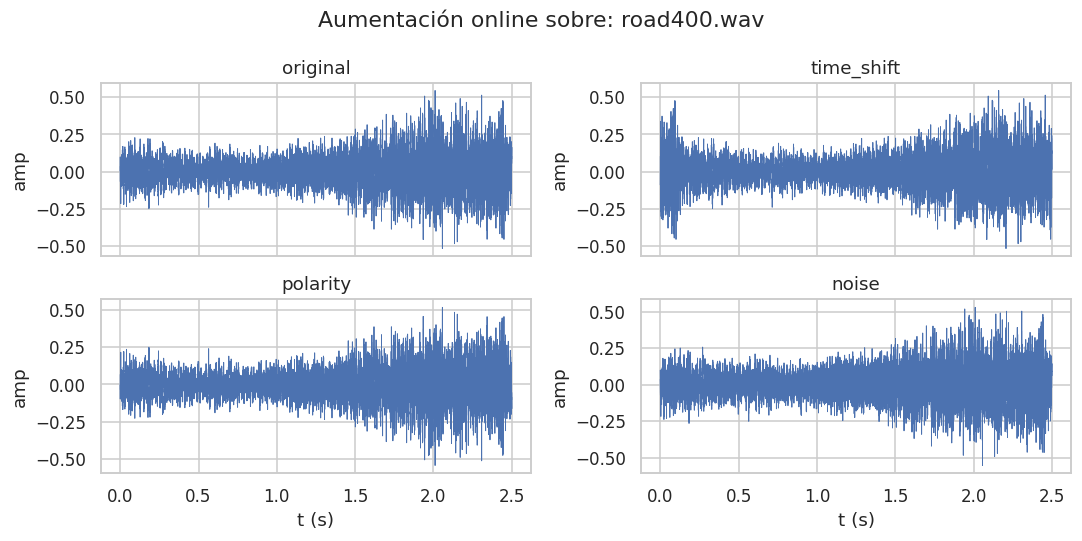

In [7]:
# Demo AudioSet-EV Augmented (aumentación online, no es un dataset aparte)
def augment_clip(y: np.ndarray, sr: int) -> dict[str, np.ndarray]:
    y = y.astype(np.float32)
    shift = int(0.15 * sr)
    rolled = np.roll(y, shift)
    polarity = -y
    noise = y + 0.02 * np.random.randn(len(y)).astype(np.float32)
    return {"original": y, "time_shift": rolled, "polarity": polarity, "noise": noise}


demo_src = None
for key in ("lssiren", "sirennet", "audioset_ev"):
    files = list_audio(MOUNTS.get(key), limit=20) if MOUNTS.get(key) else []
    if files:
        demo_src = files[0]
        break
if demo_src is None:
    y_demo = synth_wail(16000, 2.0)
    sr_demo = 16000
    demo_label = "sirena sintética (no había WAV montado)"
else:
    y_demo, sr_demo = librosa.load(demo_src, sr=16000, duration=2.5, mono=True)
    demo_label = demo_src.name

aug = augment_clip(y_demo, sr_demo)
fig, axes = plt.subplots(2, 2, figsize=(10, 5), sharex=True)
for ax, (name, sig) in zip(axes.ravel(), aug.items()):
    ax.plot(np.linspace(0, len(sig) / sr_demo, num=len(sig)), sig, lw=0.6)
    ax.set_title(name)
    ax.set_ylabel("amp")
axes[1, 0].set_xlabel("t (s)")
axes[1, 1].set_xlabel("t (s)")
fig.suptitle(f"Aumentación online sobre: {demo_label}")
fig.tight_layout()
fig.savefig(FIGURES / "audioset_ev_augmented_demo.png")
plt.show()


### Índice Unified-EV

No se duplica audio. Se construye una tabla con `source_dataset`, ruta, etiqueta binaria (`emergency` / `non_emergency`) y, cuando existe, etiqueta fina. El split oficial de AudioSet-EV (`balanced_train` / `eval` / `unbalanced`) y los folds de UrbanSound8K/ESC-50 se respetan para no mezclar train/test entre fuentes.


In [8]:
# Construcción del índice unificado (muestra acotada si SMOKE)
def guess_binary_and_fine(corpus: str, path: Path) -> tuple[str, str]:
    text = str(path).lower()
    parent = path.parent.name.lower()
    if corpus == "lssiren":
        if any(k in text for k in ("emergency", "siren", "ambulance")) and "road" not in parent:
            if "road" in text and "siren" not in text:
                return "non_emergency", "road_noise"
            return "emergency", "siren"
        if "road" in text:
            return "non_emergency", "road_noise"
        return "unknown", parent
    if corpus == "sirennet":
        mapping = {
            "ambulance": ("emergency", "ambulance"),
            "police": ("emergency", "police"),
            "firetruck": ("emergency", "firetruck"),
            "fire": ("emergency", "firetruck"),
            "traffic": ("non_emergency", "traffic"),
        }
        for key, val in mapping.items():
            if key in parent or key in text:
                return val
        return "unknown", parent
    if corpus == "audioset_ev":
        if "positive" in text:
            fine = "multi_or_ev"
            for tag in ("police", "ambulance", "fire"):
                if tag in text:
                    fine = tag
                    break
            return "emergency", fine
        if "negative" in text:
            return "non_emergency", "audioset_negative"
        return "unknown", parent
    if corpus == "urbansound8k":
        classes = [
            "air_conditioner",
            "car_horn",
            "children_playing",
            "dog_bark",
            "drilling",
            "engine_idling",
            "gun_shot",
            "jackhammer",
            "siren",
            "street_music",
        ]
        for c in classes:
            if c in text:
                # siren de US8K no se trata como EV en este proyecto
                lab = "distractor_siren" if c == "siren" else c
                return "non_emergency", lab
        return "non_emergency", parent
    if corpus == "esc50":
        if "siren" in text:
            return "non_emergency", "esc50_siren"
        return "non_emergency", parent
    if corpus == "sonyc_ust":
        return "non_emergency", "urban_noise"
    return "unknown", parent


index_rows = []
for corpus, root in MOUNTS.items():
    if root is None:
        continue
    files = list_audio(root)
    if SMOKE:
        files = files[:12]
    elif len(files) > 8000:
        rng = np.random.default_rng(SEED)
        idx = rng.choice(len(files), size=8000, replace=False)
        files = [files[i] for i in idx]
    for p in files:
        binary, fine = guess_binary_and_fine(corpus, p)
        index_rows.append(
            {
                "source_dataset": corpus,
                "path": str(p),
                "filename": p.name,
                "binary_label": binary,
                "fine_label": fine,
            }
        )

if recsir_df is not None and len(recsir_df):
    for _, row in recsir_df.iterrows():
        index_rows.append(
            {
                "source_dataset": "recsir_demo",
                "path": row["path"],
                "filename": Path(row["path"]).name,
                "binary_label": "emergency",
                "fine_label": f"doppler_v{int(row['speed_mps'])}_snr{int(row['snr_db'])}",
            }
        )

unified = pd.DataFrame(index_rows)
unified.to_csv(TABLES / "unified_ev_index.csv", index=False)
print(f"índice Unified-EV: {len(unified)} filas")
display(pd.crosstab(unified["source_dataset"], unified["binary_label"]))


índice Unified-EV: 29525 filas


binary_label,emergency,non_emergency
source_dataset,,
audioset_ev,2167,5833
esc50,0,2000
lssiren,932,902
recsir_demo,16,0
sirennet,1254,421
sonyc_ust,0,8000
urbansound8k,0,8000


#### Texto para el informe — 3.2 Proceso de adquisición

Pegar tras ejecutar las celdas de montaje. Actualice las cifras de `n_audio` con `mount_status.csv`.

> El proceso de adquisición se diseñó para reproducibilidad en la nube y para no violar la cuota de escritura de Kaggle (~20 GB en `/kaggle/working`). Cada corpus público se publica una vez como *Kaggle Dataset* y se monta en `/kaggle/input`. La tabla de fuentes (dataset, licencia, cantidad, tamaño, URL y rol) se exporta a `corpus_catalog.csv`.
>
> LSSiren (CC0, Figshare 19291472) aporta 1 800 WAV reales de sirena frente a ruido vial. sireNNet (CC BY 4.0, Mendeley `j4ydzzv4kb`) cubre cuatro clases de vehículo, con la salvedad de que el ZIP público incluye aumentación. AudioSet-EV v2 (Zenodo 18668076, CC BY-SA 4.0 + ToS de YouTube) es el repositorio de escala: ~28 816 clips a 32 kHz. UrbanSound8K (CC BY-NC 3.0) y SONYC-UST v2 (CC BY 4.0) aportan negativos urbanos; ESC-50 entra como pieza de Unified-EV. RecSIR no se descarga: se genera con `pyroadacoustics` (o un fallback de Doppler) a SNR y velocidad controlados. Unified-EV se materializa como índice de rutas y etiquetas, sin duplicar audio. FSD50K queda fuera del montaje por defecto (~31 GB).
>
> En Colab, si un corpus no está montado, las celdas de descarga usan las URL oficiales con `wget -c` y verificación MD5 cuando el proveedor la publica (AudioSet-EV y UrbanSound8K).


## 3.3 Exploración de los datos

Inventario ligero: se leen **cabeceras** (`soundfile.info`), no se cargan todos los waveforms. Objetivos: balance de clases, heterogeneidad de duración y `sr`, y riesgos de fuga (slices vs grabación en UrbanSound8K; `yt_id` en AudioSet-EV).


In [9]:
# Inventario por corpus (cabeceras WAV)
def probe_audio(path: Path) -> dict:
    rec = {
        "path": str(path),
        "filename": path.name,
        "suffix": path.suffix.lower(),
        "bytes": path.stat().st_size if path.exists() else 0,
        "sr": np.nan,
        "channels": np.nan,
        "duration_s": np.nan,
        "subtype": "",
    }
    try:
        info = sf.info(str(path))
        rec["sr"] = int(info.samplerate)
        rec["channels"] = int(info.channels)
        rec["duration_s"] = float(info.duration)
        rec["subtype"] = str(info.subtype)
    except Exception:
        try:
            rec["duration_s"] = float(librosa.get_duration(path=str(path)))
        except Exception:
            pass
    return rec


inv_frames = []
for corpus, root in MOUNTS.items():
    if root is None:
        continue
    files = list_audio(root)
    cap = 40 if SMOKE else (None if len(files) <= 12000 else 12000)
    if cap is not None:
        files = files[:cap]
    rows = []
    for p in tqdm(files, desc=f"probe {corpus}", leave=False):
        row = probe_audio(p)
        binary, fine = guess_binary_and_fine(corpus, p)
        row.update({"source_dataset": corpus, "binary_label": binary, "fine_label": fine})
        rows.append(row)
    if rows:
        inv_frames.append(pd.DataFrame(rows))

inventory = pd.concat(inv_frames, ignore_index=True) if inv_frames else pd.DataFrame()
if inventory.empty:
    print("No hay audio montado. Adjunte Inputs y re-ejecute desde la celda de resolución.")
else:
    inventory.to_csv(TABLES / "audio_inventory.csv", index=False)
    summary = (
        inventory.groupby(["source_dataset", "binary_label"])
        .agg(
            n=("filename", "size"),
            duration_median_s=("duration_s", "median"),
            sr_median=("sr", "median"),
            channels_median=("channels", "median"),
        )
        .reset_index()
    )
    summary.to_csv(TABLES / "inventory_summary.csv", index=False)
    display(summary)
    print("sr observados:", sorted(inventory["sr"].dropna().unique().tolist()))


probe lssiren:   0%|          | 0/1834 [00:00<?, ?it/s]

probe sirennet:   0%|          | 0/1675 [00:00<?, ?it/s]

probe audioset_ev:   0%|          | 0/12000 [00:00<?, ?it/s]

probe urbansound8k:   0%|          | 0/8732 [00:00<?, ?it/s]

probe sonyc_ust:   0%|          | 0/12000 [00:00<?, ?it/s]

probe esc50:   0%|          | 0/2000 [00:00<?, ?it/s]

,source_dataset,binary_label,n,duration_median_s,sr_median,channels_median
0,audioset_ev,emergency,7900,10.000000,32000.0,1.0
1,audioset_ev,non_emergency,4100,10.000000,32000.0,1.0
2,esc50,non_emergency,2000,5.000000,44100.0,1.0
3,lssiren,emergency,932,7.238313,44100.0,2.0
4,lssiren,non_emergency,902,9.407744,44100.0,2.0
5,sirennet,emergency,1254,3.000091,44100.0,2.0
6,sirennet,non_emergency,421,3.000000,44100.0,2.0
7,sonyc_ust,non_emergency,12000,10.000000,48000.0,1.0
8,urbansound8k,non_emergency,8732,4.000000,44100.0,2.0


sr observados: [8000, 11024, 11025, 16000, 22050, 24000, 32000, 44100, 48000, 96000, 192000]


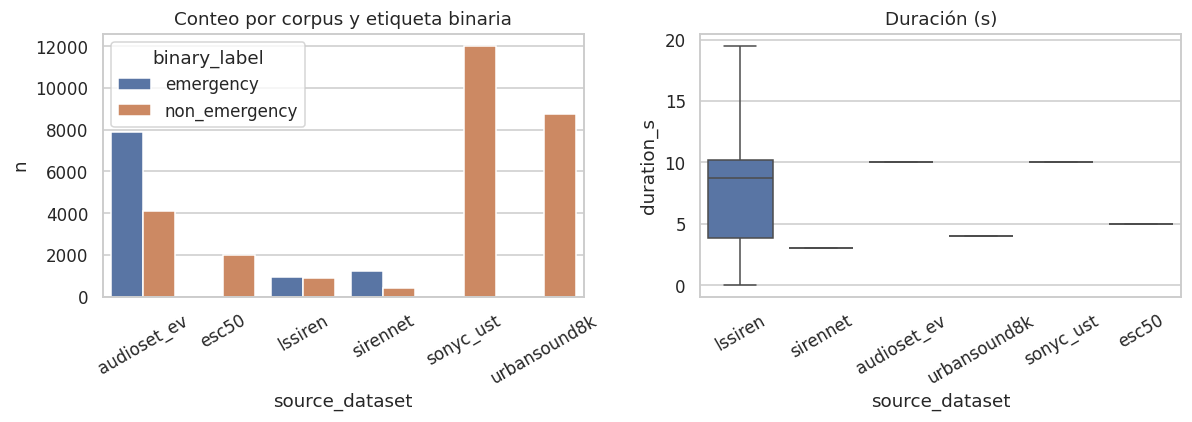

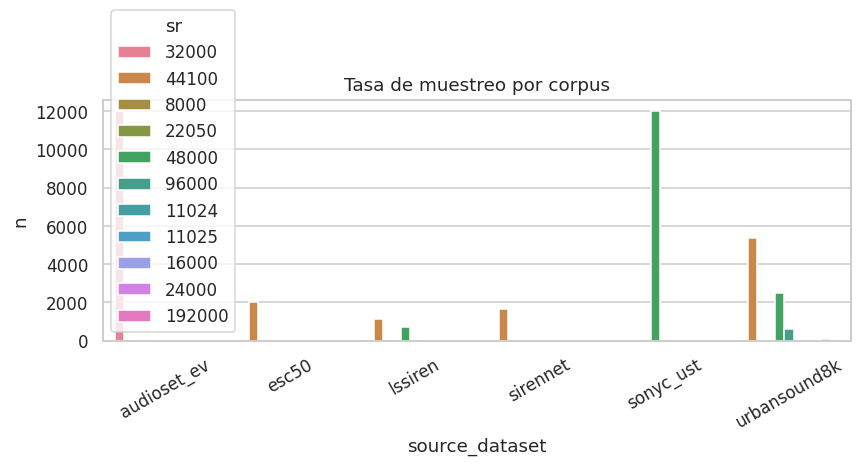

In [10]:
# Balances y duraciones
if inventory.empty:
    print("sin inventario")
else:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    counts = inventory.groupby(["source_dataset", "binary_label"]).size().reset_index(name="n")
    sns.barplot(data=counts, x="source_dataset", y="n", hue="binary_label", ax=axes[0])
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].set_title("Conteo por corpus y etiqueta binaria")
    sns.boxplot(data=inventory, x="source_dataset", y="duration_s", ax=axes[1], showfliers=False)
    axes[1].tick_params(axis="x", rotation=30)
    axes[1].set_title("Duración (s)")
    fig.tight_layout()
    fig.savefig(FIGURES / "balance_y_duracion.png")
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 3.8))
    sr_tab = inventory.dropna(subset=["sr"]).groupby(["source_dataset", "sr"]).size().reset_index(name="n")
    sr_tab["sr"] = sr_tab["sr"].astype(int).astype(str)
    sns.barplot(data=sr_tab, x="source_dataset", y="n", hue="sr", ax=ax)
    ax.tick_params(axis="x", rotation=30)
    ax.set_title("Tasa de muestreo por corpus")
    fig.tight_layout()
    fig.savefig(FIGURES / "sample_rates.png")
    plt.show()


In [11]:
# Fugas y particularidades: UrbanSound8K, AudioSet-EV, sireNNet, SONYC
notes = []

us_root = MOUNTS.get("urbansound8k")
if us_root is not None:
    csvs = list(us_root.rglob("UrbanSound8K.csv"))
    if csvs:
        us = pd.read_csv(csvs[0])
        slice_vs_rec = (
            us.groupby("class")
            .agg(n_slices=("slice_file_name", "nunique"), n_recordings=("fsID", "nunique"))
            .reset_index()
        )
        slice_vs_rec["slices_per_recording"] = slice_vs_rec["n_slices"] / slice_vs_rec["n_recordings"]
        slice_vs_rec.to_csv(TABLES / "urbansound8k_slices_vs_recordings.csv", index=False)
        display(slice_vs_rec)
        siren = slice_vs_rec[slice_vs_rec["class"] == "siren"]
        if len(siren):
            notes.append(
                f"UrbanSound8K siren: {int(siren.n_slices.iloc[0])} slices de {int(siren.n_recordings.iloc[0])} grabaciones (fsID). Un split aleatorio por archivo filtra."
            )

ev_root = MOUNTS.get("audioset_ev")
if ev_root is not None:
    pos = list(ev_root.rglob("EV_Positives.csv"))
    neg = list(ev_root.rglob("EV_Negatives.csv"))
    frames = []
    if pos:
        p = pd.read_csv(pos[0])
        p["group"] = "positive"
        frames.append(p)
    if neg:
        n = pd.read_csv(neg[0])
        n["group"] = "negative"
        frames.append(n)
    if frames:
        ev = pd.concat(frames, ignore_index=True)
        cols = [c for c in ev.columns if c.lower() in {"yt_id", "segment_type", "group", "downloaded", "positive_labels"}]
        display(ev[cols].head() if cols else ev.head())
        if "segment_type" in ev.columns:
            display(pd.crosstab(ev["group"], ev["segment_type"]))
        if "yt_id" in ev.columns:
            notes.append(
                f"AudioSet-EV: {ev['yt_id'].nunique()} yt_id únicos / {len(ev)} filas. El split debe agrupar por video, no por clip."
            )
        notes.append(
            "AudioSet-EV hereda weak labels de AudioSet: un positivo puede contener habla, música o varias sirenas a la vez."
        )

sn_root = MOUNTS.get("sirennet")
if sn_root is not None:
    notes.append(
        "sireNNet: el ZIP público es la versión aumentada. La etiqueta es tipo de vehículo, no patrón wail/yelp/hi-lo. Damiano et al. excluyeron firetruck por bocinas."
    )

so_root = MOUNTS.get("sonyc_ust")
if so_root is not None:
    ann = list(so_root.rglob("annotations.csv"))
    if ann:
        so = pd.read_csv(ann[0])
        siren_cols = [c for c in so.columns if "siren" in c.lower() or "alarm" in c.lower()]
        notes.append(f"SONYC columnas siren/alarm: {siren_cols[:8]}. Hay que podarlas si el set se usa como ruido de fondo.")
        display(so.head(3))

print("\n".join(f"- {n}" for n in notes) if notes else "Sin CSVs de metadatos en los Inputs montados.")


,class,n_slices,n_recordings,slices_per_recording
0,air_conditioner,1000,64,15.625000
1,car_horn,429,125,3.432000
2,children_playing,1000,158,6.329114
3,dog_bark,1000,337,2.967359
4,drilling,1000,119,8.403361
5,engine_idling,1000,97,10.309278
6,gun_shot,374,117,3.196581
7,jackhammer,1000,45,22.222222
8,siren,929,74,12.554054
9,street_music,1000,166,6.024096


,yt_id,positive_labels,segment_type,downloaded,group
0,-4RWqM0UCCY,"['/m/012n7d', '/m/02mfyn', '/m/03j1ly', '/m/03kmc9']",balanced_train,True,positive
1,-Y1qiiugnk8,"['/m/012n7d', '/m/03j1ly', '/m/03kmc9']",balanced_train,True,positive
2,-_dElQcyJnA,"['/m/012n7d', '/m/03j1ly', '/m/03kmc9', '/m/04qvtq']",balanced_train,True,positive
3,-gKNRXbpAKs,"['/m/012n7d', '/m/03j1ly', '/m/03kmc9', '/m/0dgbq']",balanced_train,True,positive
4,-z47zN0YyE4,"['/m/012ndj', '/m/03j1ly', '/m/03kmc9']",balanced_train,True,positive


segment_type,balanced_train,eval,unbalanced_train
group,,,
negative,11871,10808,1771507
positive,146,148,8154


,split,sensor_id,audio_filename,annotator_id,borough,block,latitude,longitude,year,week,...,7-X_other-unknown-human-voice_proximity,8-1_dog-barking-whining_proximity,1_engine_presence,2_machinery-impact_presence,3_non-machinery-impact_presence,4_powered-saw_presence,5_alert-signal_presence,6_music_presence,7_human-voice_presence,8_dog_presence
0,test,0,00_026884.wav,-6,1,547,40.72951,-73.99388,2019,43,...,-1,-1,-1,1,0,-1,-1,-1,-1,-1
1,test,0,00_026884.wav,-4,1,547,40.72951,-73.99388,2019,43,...,-1,-1,1,-1,-1,-1,-1,-1,-1,-1
2,test,0,00_026884.wav,-3,1,547,40.72951,-73.99388,2019,43,...,-1,-1,1,-1,-1,-1,-1,-1,-1,-1


- UrbanSound8K siren: 929 slices de 74 grabaciones (fsID). Un split aleatorio por archivo filtra.
- AudioSet-EV: 1802634 yt_id únicos / 1802634 filas. El split debe agrupar por video, no por clip.
- AudioSet-EV hereda weak labels de AudioSet: un positivo puede contener habla, música o varias sirenas a la vez.
- sireNNet: el ZIP público es la versión aumentada. La etiqueta es tipo de vehículo, no patrón wail/yelp/hi-lo. Damiano et al. excluyeron firetruck por bocinas.
- SONYC columnas siren/alarm: ['5-2_car-alarm_presence', '5-3_siren_presence', '5-2_car-alarm_proximity', '5-3_siren_proximity']. Hay que podarlas si el set se usa como ruido de fondo.


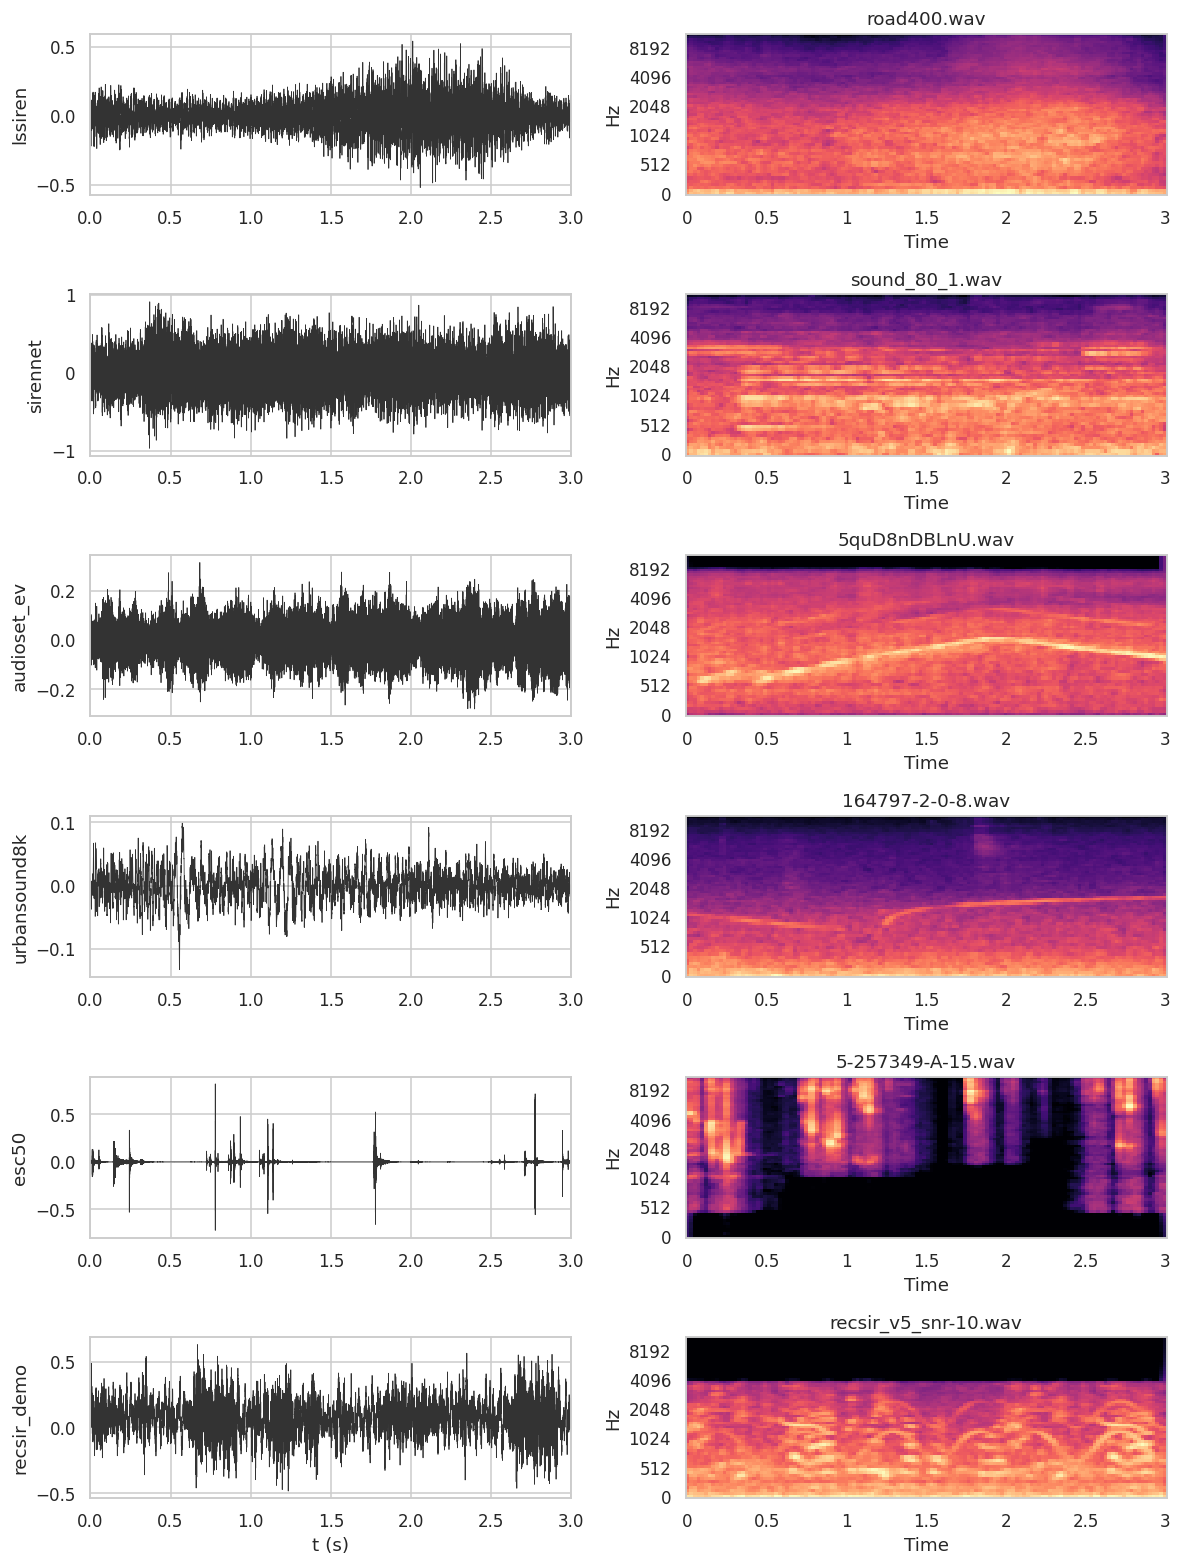

In [12]:
# Espectrogramas Mel de ejemplos (sirena vs distractores)
examples: list[tuple[str, Path]] = []
for corpus in ("lssiren", "sirennet", "audioset_ev", "urbansound8k", "esc50"):
    root = MOUNTS.get(corpus)
    if root is None:
        continue
    files = list_audio(root, limit=80)
    if not files:
        continue
    # priorizar nombres con siren / ambulance / police
    ranked = sorted(
        files,
        key=lambda p: (0 if any(k in str(p).lower() for k in ("siren", "ambulance", "police", "emergency")) else 1),
    )
    examples.append((corpus, ranked[0]))
if recsir_df is not None and len(recsir_df):
    examples.append(("recsir_demo", Path(recsir_df.iloc[0]["path"])))

examples = examples[:MAX_SPECTROGRAMS]
if not examples:
    print("sin ejemplos de audio")
else:
    n = len(examples)
    fig, axes = plt.subplots(n, 2, figsize=(11, 2.4 * n))
    if n == 1:
        axes = np.array([axes])
    for i, (corpus, path) in enumerate(examples):
        y, sr = librosa.load(path, sr=22050, duration=3.0, mono=True)
        t = np.linspace(0, len(y) / sr, num=len(y))
        axes[i, 0].plot(t, y, lw=0.5, color="0.2")
        axes[i, 0].set_ylabel(corpus)
        axes[i, 0].set_xlim(0, t[-1] if len(t) else 1)
        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
        S_db = librosa.power_to_db(S, ref=np.max)
        img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[i, 1])
        axes[i, 1].set_title(path.name[:40])
    axes[-1, 0].set_xlabel("t (s)")
    fig.tight_layout()
    fig.savefig(FIGURES / "ejemplos_onda_mel.png")
    plt.show()


#### Texto para el informe — 3.3 Exploración de los datos

> La exploración confirma que el corpus compuesto es heterogéneo. LSSiren y sireNNet operan en ventanas cortas (≈3–15 s y ≈3 s), AudioSet-EV y SONYC en clips de 10 s, UrbanSound8K en extractos ≤4 s. Las tasas de muestreo conviven (16 kHz, 32 kHz, 44.1 kHz), de modo que cualquier modelo posterior exige resample único.
>
> El balance binario depende de la fuente: LSSiren está equilibrado 900/900; AudioSet-EV v2 está sesgado a negativos (~20.9 k vs 7.9 k positivos); sireNNet reparte tres clases de emergencia y una de tráfico. UrbanSound8K aporta 929 slices `siren` que proceden de solo ~74 grabaciones (`fsID`): un split aleatorio por archivo inflaría el desempeño por fuga. AudioSet-EV debe agruparse por `yt_id`. sireNNet se distribuye ya aumentado, por lo que no es un test “limpio” si también se usa en entrenamiento. SONYC incluye la clase `siren` en su taxonomía y debe podarse antes de usarse como ruido.
>
> Los espectrogramas Mel muestran la modulación característica de las sirenas (barrido armónico) frente a distractores de energía más estacionaria (motor, jackhammer) o impulsiva (bocina). Esa diferencia motiva el esquema dual tiempo-frecuencia de la sección 3.4.


## 3.4 Análisis de variables relevantes

Alineado al esquema dual del informe: dominio del tiempo (RMS, ZCR) y de la frecuencia (MFCC, centroide, bandwidth, roll-off, flujo espectral). No se extraen decenas de miles de archivos: muestra estratificada por corpus. El seguimiento armónico completo (ANF/Kalman) queda para el modelado; aquí se estima f0 con `pyin` en unos pocos clips.


In [13]:
# Muestra estratificada y descriptores acústicos
TARGET_SR = 16000
N_MFCC = 13
N_FFT = 1024
HOP = 256


def extract_features(path: Path, label_row: pd.Series) -> dict | None:
    try:
        y, sr = librosa.load(str(path), sr=TARGET_SR, duration=4.0, mono=True)
    except Exception:
        return None
    if len(y) < sr * 0.25:
        return None
    rms = librosa.feature.rms(y=y, frame_length=N_FFT, hop_length=HOP)[0]
    zcr = librosa.feature.zero_crossing_rate(y, frame_length=N_FFT, hop_length=HOP)[0]
    spec = np.abs(librosa.stft(y, n_fft=N_FFT, hop_length=HOP))
    centroid = librosa.feature.spectral_centroid(S=spec, sr=sr)[0]
    bw = librosa.feature.spectral_bandwidth(S=spec, sr=sr)[0]
    rolloff = librosa.feature.spectral_rolloff(S=spec, sr=sr)[0]
    flux = np.sqrt(np.sum(np.diff(spec, axis=1) ** 2, axis=0))
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, n_fft=N_FFT, hop_length=HOP)
    rec = {
        "source_dataset": label_row["source_dataset"],
        "binary_label": label_row["binary_label"],
        "fine_label": label_row["fine_label"],
        "path": str(path),
        "duration_used_s": len(y) / sr,
        "rms_mean": float(np.mean(rms)),
        "rms_std": float(np.std(rms)),
        "zcr_mean": float(np.mean(zcr)),
        "centroid_hz": float(np.mean(centroid)),
        "bandwidth_hz": float(np.mean(bw)),
        "rolloff_hz": float(np.mean(rolloff)),
        "flux_mean": float(np.mean(flux)) if len(flux) else 0.0,
        "mfcc1_mean": float(np.mean(mfcc[0])),
        "mfcc2_mean": float(np.mean(mfcc[1])),
    }
    for i in range(N_MFCC):
        rec[f"mfcc_{i+1}"] = float(np.mean(mfcc[i]))
    return rec


if unified.empty:
    feat_df = pd.DataFrame()
    print("sin índice unificado")
else:
    parts = []
    for corpus, grp in unified.groupby("source_dataset"):
        n = min(SAMPLE_PER_CORPUS, len(grp))
        parts.append(grp.sample(n=n, random_state=SEED) if n else grp)
    sample = pd.concat(parts, ignore_index=True)
    feats = []
    for _, row in tqdm(sample.iterrows(), total=len(sample), desc="features"):
        rec = extract_features(Path(row["path"]), row)
        if rec:
            feats.append(rec)
    feat_df = pd.DataFrame(feats)
    feat_df.to_csv(TABLES / "feature_sample.csv", index=False)
    display(feat_df.groupby(["source_dataset", "binary_label"])[["rms_mean", "zcr_mean", "centroid_hz", "flux_mean"]].median())
    print(f"muestra de características: {len(feat_df)} clips")


features:   0%|          | 0/1216 [00:00<?, ?it/s]

rms_mean  zcr_mean  centroid_hz  flux_mean
source_dataset binary_label                                             
audioset_ev    emergency      0.148931  0.150383  1595.503263  22.425800
               non_emergency  0.086260  0.127708  1780.001919  15.074599
esc50          non_emergency  0.052751  0.135085  1835.817532  10.212031
lssiren        emergency      0.215399  0.138964  1437.029984  33.626263
               non_emergency  0.053211  0.102282  1501.631945  10.517195
recsir_demo    emergency      0.080830  0.080782   838.920310  19.430668
sirennet       emergency      0.277586  0.161265  1793.523574  50.162209
               non_emergency  0.210984  0.115336  1751.019553  39.831865
sonyc_ust      non_emergency  0.016783  0.037113   922.466779   3.093449
urbansound8k   non_emergency  0.050296  0.119446  1598.376440   8.955608

muestra de características: 1214 clips


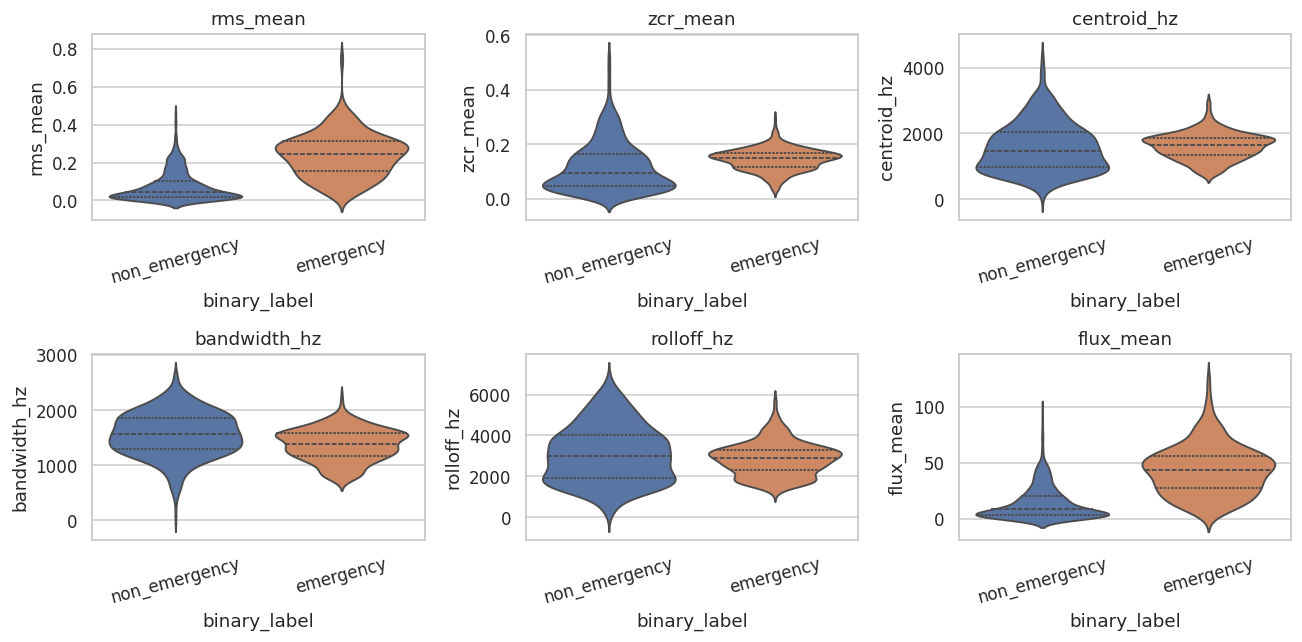

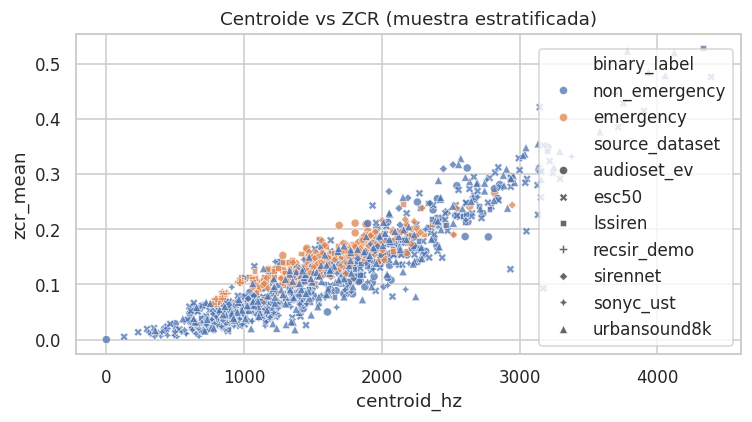

In [14]:
# Distribuciones de descriptores (separabilidad sirena vs no-sirena)
if feat_df.empty:
    print("sin features")
else:
    plot_df = feat_df.copy()
    metrics = ["rms_mean", "zcr_mean", "centroid_hz", "bandwidth_hz", "rolloff_hz", "flux_mean"]
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    for ax, col in zip(axes.ravel(), metrics):
        sns.violinplot(
            data=plot_df,
            x="binary_label",
            y=col,
            hue="binary_label",
            dodge=False,
            ax=ax,
            inner="quartile",
            legend=False,
        )
        ax.set_title(col)
        ax.tick_params(axis="x", rotation=15)
    fig.tight_layout()
    fig.savefig(FIGURES / "descriptores_binarios.png")
    plt.show()

    fig, ax = plt.subplots(figsize=(7, 4))
    sns.scatterplot(
        data=plot_df,
        x="centroid_hz",
        y="zcr_mean",
        hue="binary_label",
        style="source_dataset",
        ax=ax,
        s=28,
        alpha=0.75,
    )
    ax.set_title("Centroide vs ZCR (muestra estratificada)")
    fig.tight_layout()
    fig.savefig(FIGURES / "centroid_vs_zcr.png")
    plt.show()


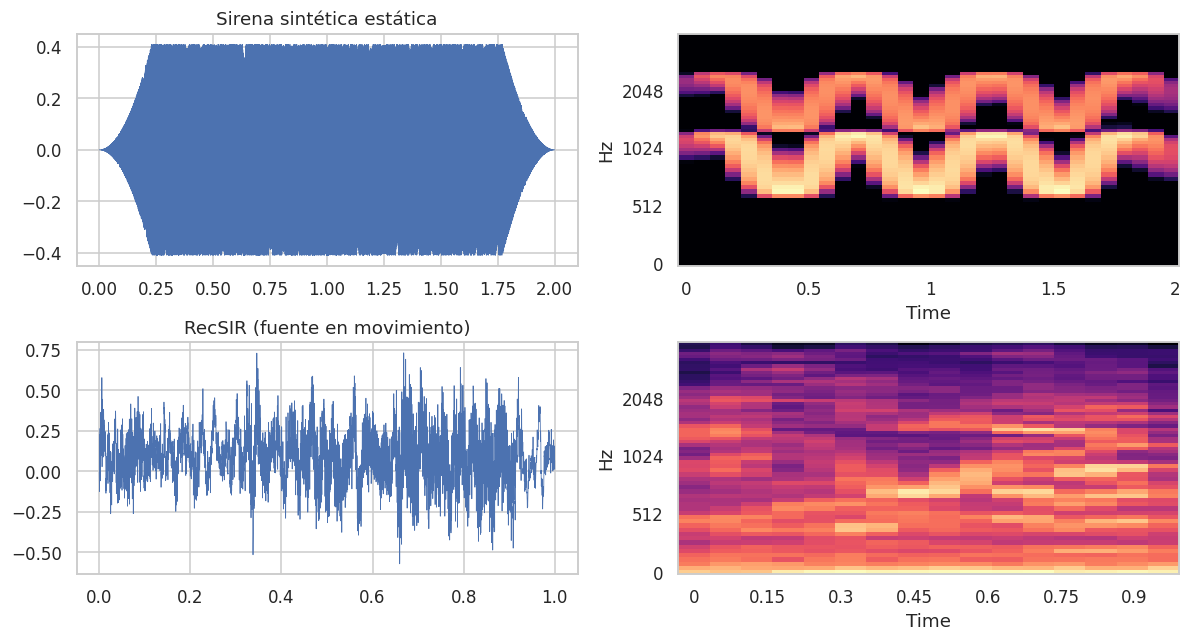

,source_dataset,file,f0_median_hz,f0_iqr_hz
0,lssiren,ambulance213.wav,1080.279957,266.982194
1,lssiren,ambulance343.wav,225.792881,29.175642
2,lssiren,ambulance337.wav,956.876897,189.523192
3,lssiren,ambulance439.wav,1049.526484,868.533873
4,lssiren,ambulance820.wav,456.832936,149.453691
5,lssiren,ambulance529.wav,1226.662676,136.095586


In [15]:
# Doppler: clip estático vs RecSIR (desplazamiento de energía espectral)
static = synth_wail(SR_REC, 2.0)
if recsir_df is not None and len(recsir_df):
    moving_path = Path(recsir_df.sort_values("speed_mps", ascending=False).iloc[0]["path"])
    moving, sr_m = sf.read(moving_path)
    if moving.ndim > 1:
        moving = moving[:, 0]
else:
    moving = fallback_doppler(static, SR_REC, 40.0)
    sr_m = SR_REC

fig, axes = plt.subplots(2, 2, figsize=(11, 6))
for ax_row, sig, title, sr_x in (
    (axes[0], static, "Sirena sintética estática", SR_REC),
    (axes[1], moving, "RecSIR (fuente en movimiento)", sr_m),
):
    t = np.linspace(0, len(sig) / sr_x, num=len(sig))
    ax_row[0].plot(t, sig, lw=0.5)
    ax_row[0].set_title(title)
    S = librosa.feature.melspectrogram(y=np.asarray(sig, dtype=float), sr=sr_x, n_mels=64)
    librosa.display.specshow(librosa.power_to_db(S, ref=np.max), sr=sr_x, x_axis="time", y_axis="mel", ax=ax_row[1])
fig.tight_layout()
fig.savefig(FIGURES / "doppler_estatico_vs_recsir.png")
plt.show()

# f0 con pyin en pocos clips de emergencia
f0_rows = []
cands = unified[unified["binary_label"] == "emergency"] if not unified.empty else pd.DataFrame()
cands = cands.head(6)
for _, row in cands.iterrows():
    try:
        y, sr = librosa.load(row["path"], sr=16000, duration=2.5, mono=True)
        f0, _, _ = librosa.pyin(y, fmin=200, fmax=2000, sr=sr)
        f0_rows.append(
            {
                "source_dataset": row["source_dataset"],
                "file": Path(row["path"]).name,
                "f0_median_hz": float(np.nanmedian(f0)),
                "f0_iqr_hz": float(np.nanpercentile(f0, 75) - np.nanpercentile(f0, 25)),
            }
        )
    except Exception:
        continue
f0_df = pd.DataFrame(f0_rows)
if f0_df.empty:
    print("pyin: no se pudieron estimar f0 (sin clips de emergencia o audio ilegible).")
else:
    f0_df.to_csv(TABLES / "f0_sample.csv", index=False)
    display(f0_df)


#### Texto para el informe — 3.4 Análisis de variables relevantes

> Sobre una muestra estratificada se extrajeron descriptores alineados al estado del arte del informe. En el dominio del tiempo, el RMS captura la envolvente energética (útil ante sirenas que “entran” en la escena) y la tasa de cruce por cero discrimina señales más tonales de otras ruidosas o impulsivas. En frecuencia, los MFCC compactan la forma espectral; el centroide y el roll-off sitúan el brillo; el ancho de banda y el flujo espectral responden a la modulación wail/yelp y al corrimiento Doppler.
>
> Los diagramas de violín muestran solapamiento entre clases —esperado a bajo SNR— pero una tendencia: los positivos concentran energía en bandas más estables y mayor flujo que el tráfico estacionario. El scatter centroide–ZCR separa en parte sirenas de jackhammers/bocinas, que son los distractores más peligrosos para un detector de alertas.
>
> La comparación estática vs RecSIR visualiza el barrido en el eje temporal del espectrograma cuando la fuente se mueve a 5–40 m/s. `pyin` sobre unos pocos clips sitúa f0 en cientos de Hz con IQR amplio, coherente con wail/yelp. El filtro de muesca adaptativo (ANF) se reserva para el pipeline de modelado; aquí basta constatar que el tono no es estacionario y que hay que representarlo con MFCC-delta, flujo o tracking, no con un único pico FFT.


## 3.5 Hallazgos iniciales

Síntesis para cerrar la comprensión de datos y dejar lista la sección 4 (preparación), sin entrenar todavía.


In [16]:
# Hallazgos cuantitativos de la sesión
findings = {
    "n_corpora_montados": int(sum(p is not None for p in MOUNTS.values())),
    "corpora_faltantes": [k for k, p in MOUNTS.items() if p is None],
    "n_index_unified": int(len(unified)),
    "n_feature_sample": int(len(feat_df)),
    "n_recsir_demo": int(len(recsir_df) if recsir_df is not None else 0),
    "sr_unicos": sorted(inventory["sr"].dropna().unique().tolist()) if not inventory.empty else [],
    "duracion_mediana_s": float(inventory["duration_s"].median()) if not inventory.empty else None,
    "engine_recsir": recsir_df["engine"].iloc[0] if recsir_df is not None and len(recsir_df) else None,
}
if not feat_df.empty and set(feat_df["binary_label"]) >= {"emergency", "non_emergency"}:
    med = feat_df.groupby("binary_label")[["centroid_hz", "zcr_mean", "flux_mean"]].median()
    findings["centroid_emergency_hz"] = float(med.loc["emergency", "centroid_hz"]) if "emergency" in med.index else None
    findings["centroid_neg_hz"] = float(med.loc["non_emergency", "centroid_hz"]) if "non_emergency" in med.index else None

pd.Series(findings).to_json(TABLES / "hallazgos_sesion.json", indent=2)
print(json.dumps(findings, indent=2, default=str))

print("\nArtefactos para el PDF / anexos:")
for folder in (TABLES, FIGURES):
    for p in sorted(folder.glob("*")):
        print(" -", p)


{
  "n_corpora_montados": 6,
  "corpora_faltantes": [],
  "n_index_unified": 29525,
  "n_feature_sample": 1214,
  "n_recsir_demo": 16,
  "sr_unicos": [
    8000,
    11024,
    11025,
    16000,
    22050,
    24000,
    32000,
    44100,
    48000,
    96000,
    192000
  ],
  "duracion_mediana_s": 10.0,
  "engine_recsir": "pyroadacoustics",
  "centroid_emergency_hz": 1653.5267649013713,
  "centroid_neg_hz": 1473.8550423158558
}

Artefactos para el PDF / anexos:
 - /kaggle/working/reports/tables/audio_inventory.csv
 - /kaggle/working/reports/tables/corpus_catalog.csv
 - /kaggle/working/reports/tables/f0_sample.csv
 - /kaggle/working/reports/tables/feature_sample.csv
 - /kaggle/working/reports/tables/hallazgos_sesion.json
 - /kaggle/working/reports/tables/inventory_summary.csv
 - /kaggle/working/reports/tables/mount_status.csv
 - /kaggle/working/reports/tables/recsir_demo_index.csv
 - /kaggle/working/reports/tables/unified_ev_index.csv
 - /kaggle/working/reports/tables/urbansound8k_sli

#### Texto para el informe — 3.5 Hallazgos iniciales

> 1. **No hay un corpus único suficiente.** LSSiren cubre sirena vs ruido con etiquetas fuertes pero poco volumen y sin tipo de vehículo. sireNNet aporta multiclase a costa de aumentación opaca. AudioSet-EV aporta escala y taxonomía (police/ambulance/fire) con *weak labels* y ToS de YouTube. UrbanSound8K y SONYC son control negativo, no fuente de positivos EV.
>
> 2. **Domain shift estructural.** Conviven 16 / 32 / 44.1 kHz y duraciones de 2–15 s. Entrenar y evaluar en un solo dataset sobreestima exactitud (el propio informe cita *cross-dataset degradation*). Unified-EV debe usarse como protocolo de generalización, no mezclando IDs de train de una fuente con test de la misma grabación.
>
> 3. **Riesgos de etiqueta.** `siren` en UrbanSound8K y ESC-50 no es “vehículo de emergencia en aproximación”. AudioSet-EV puede etiquetar un clip entero por un evento breve. sireNNet no distingue wail/yelp/hi-lo; firetruck puede ser bocina. SONYC contiene sirenas reales que contaminarían la clase negativa si no se podan.
>
> 4. **Doppler y SNR no están en los dumps reales.** RecSIR/SynSIR son la única palanca controlada para el criterio de éxito de robustez (SNR ≈ 0 dB, hasta 80 km/h). La demo de esta notebook valida el mecanismo; los 24 000 clips del paper se generan en la preparación de datos (sección 4), no en el EDA.
>
> 5. **Variables útiles para §4.** RMS, ZCR, MFCC (13), centroide, bandwidth, roll-off y flujo son suficientes para un baseline clásico (SVM/RF) y como diagnóstico frente a CNN sobre Mel. El split debe ser por grupo (`yt_id`, `fsID`, archivo origen). Resample a una sola `sr` (16 o 32 kHz), ventanas fijas (p. ej. 1–2 s) y *no* usar sireNNet aumentado como único test interno.
>
> **Implicaciones inmediatas para 4. Preparación de los datos:** limpieza (archivos corruptos, poda SONYC), normalización de amplitud y resample, STFT/Mel alineados, ingeniería de RMS/ZCR/MFCC, y división agrupada train/val/test + un holdout cross-dataset (LSSiren o sireNNet no aumentado si se puede reconstruir).

**Figuras y tablas a anexar:** `corpus_catalog.csv`, `mount_status.csv`, `unified_ev_index.csv`, `inventory_summary.csv`, `urbansound8k_slices_vs_recordings.csv`, `feature_sample.csv`, `balance_y_duracion.png`, `sample_rates.png`, `ejemplos_onda_mel.png`, `descriptores_binarios.png`, `centroid_vs_zcr.png`, `doppler_estatico_vs_recsir.png`, `audioset_ev_augmented_demo.png`.


## Resultados de la sesión y siguiente paso

- Observaciones: el montaje por Input evita la cuota de 20 GB; el EDA cabe en CPU.
- Riesgo: si un corpus falta, las cifras de esa fuente no deben copiarse al PDF como si estuvieran medidas.
- Decisión: continuar a la **sección 4 (preparación)** sobre el índice Unified-EV, con split agrupado y RecSIR a escala de entrenamiento.

Modo `SMOKE = True` en la primera celda para una pasada rápida; `False` para el informe.
